In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
df = pd.read_csv(r'C:\Users\hemanth kumar\OneDrive\Desktop\IPL-Data-Analysis\data\matches.csv')

In [3]:
print(df.head())

       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  18-04-2008     League     BB McCullum   
1  335983  2007/08  Chandigarh  19-04-2008     League      MEK Hussey   
2  335984  2007/08       Delhi  19-04-2008     League     MF Maharoof   
3  335985  2007/08      Mumbai  20-04-2008     League      MV Boucher   
4  335986  2007/08     Kolkata  20-04-2008     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner toss_decision  \
0        Kolkat

In [4]:
print(df.shape)

(1095, 17)


In [5]:
print(df.isnull().sum())

id                  0
season              0
city               51
date                0
match_type          0
player_of_match     5
venue               0
team1               0
team2               0
toss_winner         0
toss_decision       0
winner              5
result              0
result_margin      19
target_runs         3
target_overs        3
super_over          0
dtype: int64


In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
dtypes: float64(3), int64(1), 

In [7]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check missing values
print(df.isnull().sum())

# Remove rows without winner
df = df.dropna(subset=["winner"])

# Check seasons
print(df["season"].unique())

id                  0
season              0
city               51
date                0
match_type          0
player_of_match     5
venue               0
team1               0
team2               0
toss_winner         0
toss_decision       0
winner              5
result              0
result_margin      19
target_runs         3
target_overs        3
super_over          0
dtype: int64
<ArrowStringArray>
['2007/08',    '2009', '2009/10',    '2011',    '2012',    '2013',    '2014',
    '2015',    '2016',    '2017',    '2018',    '2019', '2020/21',    '2021',
    '2022',    '2023',    '2024']
Length: 17, dtype: str


In [8]:
team_wins = df["winner"].value_counts()

print(team_wins)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64


In [9]:
team_matches = pd.concat([
    df["team1"],
    df["team2"]
]).value_counts()

win_percentage = (team_wins / team_matches * 100).sort_values(ascending=False)

print(win_percentage)

winner
Rising Pune Supergiant         62.500000
Gujarat Titans                 62.222222
Chennai Super Kings            58.227848
Lucknow Super Giants           55.813953
Mumbai Indians                 55.172414
Delhi Capitals                 52.747253
Kolkata Knight Riders          52.191235
Rajasthan Royals               51.141553
Royal Challengers Bangalore    48.945148
Sunrisers Hyderabad            48.351648
Royal Challengers Bengaluru    46.666667
Kings XI Punjab                46.315789
Gujarat Lions                  43.333333
Punjab Kings                   42.857143
Kochi Tuskers Kerala           42.857143
Delhi Daredevils               42.138365
Deccan Chargers                38.666667
Rising Pune Supergiants        35.714286
Pune Warriors                  26.666667
Name: count, dtype: float64


In [10]:
toss_match_win = (df["toss_winner"] == df["winner"]).mean() * 100

print(f"Toss winner also won the match: {toss_match_win:.2f}%")

Toss winner also won the match: 50.83%


In [11]:
season_stats = df.groupby("season").agg(
    matches=("id", "count"),
    wins=("winner", "count")
)

print(season_stats)

         matches  wins
season                
2007/08       58    58
2009          57    57
2009/10       60    60
2011          72    72
2012          74    74
2013          76    76
2014          60    60
2015          57    57
2016          60    60
2017          59    59
2018          60    60
2019          59    59
2020/21       60    60
2021          60    60
2022          74    74
2023          73    73
2024          71    71


FileNotFoundError: [Errno 2] No such file or directory: 'visuals/team_wins.png'

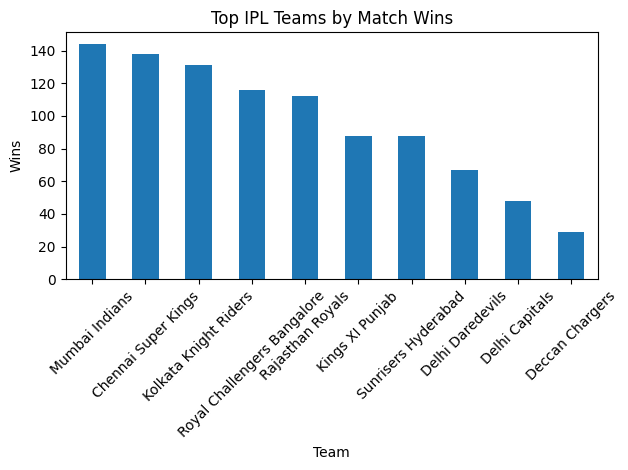

In [12]:
team_wins.head(10).plot(kind="bar")

plt.title("Top IPL Teams by Match Wins")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("visuals/team_wins.png")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'visuals/season_matches.png'

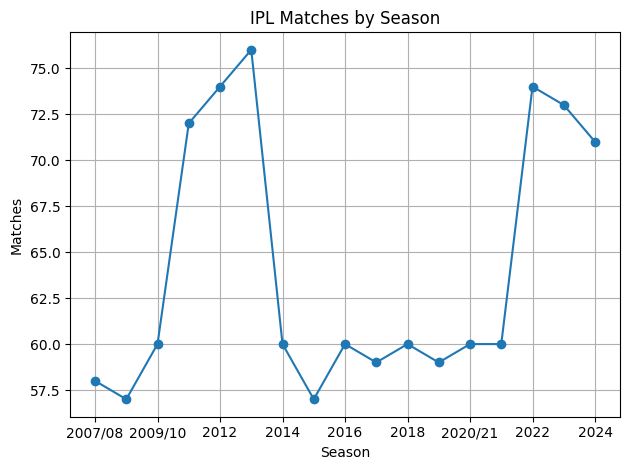

In [13]:
season_matches = df["season"].value_counts().sort_index()

season_matches.plot(kind="line", marker="o")

plt.title("IPL Matches by Season")
plt.xlabel("Season")
plt.ylabel("Matches")
plt.grid()
plt.tight_layout()
plt.savefig("visuals/season_matches.png")
plt.show()